# Every Growth Rate has its day

CAGR or Compound Annual Growth Rate is a popular growth rate used as a mathematical summary of historical trend of many time-series data including funds in stock market, disease burden, exchange rates, etc. However, it suffers from a well-known problem of inability to capture intermediate volatility and risks. This is to be expected since the CAGR depends only on the end timepoints of the time-series to smoothen the curve.

For a more modest smoothening that accounts for intermediate variations as well, we adapt the Thiel-Sen slope and normalize it in 4 ways to get a TS-growth rate. Our initial null-hypothesis was *"TS-growth rate is universally better than CAGR"*. We tested this hypothesis by performing one-step ahead forecasting (using data from $t=0$ to $t=T$ to predict for $t=(T+1)$). Comparing both $R^2$ metric and $RMSLE$, we did observe that on average our TS-growth rate performed better than CAGR. However, putting both against the naive forecast ($\hat{y}_{T+1} = y_T$) performed better than both our growth-rates.

This is also fairly reasonable for two reasons: One, these growth rates are capturing long-term trends, and in case of one-step prediction, the most recent history is more important than long-term unlike in the case of longer forecasting horizon. Two, these growth rates are designed more to summarize historical trend and less to forecast further.For these reasons, we adjust our focus to finding the cases where our TS-growth rate captures the trend better than CAGR. So, we define the following experiments:

- **Experiment 1:** Goodness of fit - Compare the smoothened curve by each growth rate and real curve to see which growth rate captures the trend better.
- **Experiment 2:** Predictive power - Here, we do two-step or three-step prediction using the historical data

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()

True

## Auxiliaries

In [2]:
DATA_DIR = os.getenv("DATA_FOLDER")
RESULTS_DIR = "data"
NORM_MODES = ["mean", "median", "interval", "base"]

In [3]:
def get_cagr(values:list):
    """
    Calculate the Compound Annual Growth Rate (CAGR).
    """
    if len(values) < 2:
        return None  # Not enough data to calculate CAGR
    start_value = values[0]
    end_value = values[-1]
    periods = len(values) - 1
    if start_value <= 0 or end_value < 0:
        return None  # Invalid values for CAGR calculation
    cagr = 100 * ((end_value / start_value) ** (1 / periods) - 1)
    return cagr

def get_lagr(values:list):
    """
    Calculate the Linear Annual Growth Rate (LAGR).
    """
    if len(values) < 2:
        return None  # Not enough data to calculate LAGR
    prev, curr = values[-2], values[-1]
    if prev <= 0 or curr < 0:
        return None  # Invalid values for LAGR calculation
    lagr = 100 * ((curr / prev) - 1)
    return lagr

def goodness_of_fit(actuals, preds, metric="rmse"):
    """
    Calculate the goodness of fit between actual and predicted values.
    Supported metrics: "rmse", "mae", "mape"
    """
    if metric == "rmse":
        return math.sqrt(np.mean((np.array(actuals) - np.array(preds)) ** 2))
    elif metric == "mae":
        return np.mean(np.abs(np.array(actuals) - np.array(preds)))
    elif metric == "mape":
        return np.mean(np.abs((np.array(actuals) - np.array(preds)) / np.array(actuals))) * 100
    elif metric == "rpr": # Roughness Preservation Ratio
        # return np.sum(np.abs(np.diff(preds))) / np.sum(np.abs(np.diff(actuals)))
        return np.std((np.diff(preds))) / np.std((np.diff(actuals)))
    else:
        raise ValueError(f"Unsupported metric: {metric}")

In [4]:
a = [1,3,2,4,5]
np.diff(a)

array([ 2, -1,  2,  1])

## Epidemiology

In [5]:
df = pd.read_csv(os.path.join(DATA_DIR, "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [6]:
cols = ["Year", "Location", "Cause", "Sex", "Measure"]
df = df[(df["Age"] == "All ages") & (df["Sex"].isin(["Male", "Female"])) & (df["Cause"] != "All causes of disease and injury") & (df["Location"] != "Scotland")][cols]
df["Year"] = df["Year"].astype(int)
df["Measure"] = df["Measure"].str.strip().str.replace(",", "").astype(float)
df.head()

,Year,Location,Cause,Sex,Measure
138240,2014,East Scotland,HIV/AIDS and tuberculosis,Male,29.7
138241,2014,East Scotland,HIV/AIDS and tuberculosis,Female,15.4
138243,2014,East Scotland,Lower respiratory infections,Male,686.1
138244,2014,East Scotland,Lower respiratory infections,Female,539.9
138246,2014,East Scotland,Diarrhoea and other common infections,Male,169.8


In [7]:
# For each (Location, Cause, Sex) group, aggregate the annual data as a list of (year, count) tuples and assign it in a new column in dataframe
df = df.groupby(["Location", "Cause", "Sex"]).apply(
    lambda x: x[["Year", "Measure"]].values.tolist()
).reset_index(name="YearlyData")
df["YearlyData"] = df["YearlyData"].apply(lambda x: [tuple(t) for t in x])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Location    2380 non-null   str   
 1   Cause       2380 non-null   str   
 2   Sex         2380 non-null   str   
 3   YearlyData  2380 non-null   object
dtypes: object(1), str(3)
memory usage: 74.5+ KB


In [8]:
df["CAGR"] = df["YearlyData"].apply(lambda x: get_cagr([t[1] for t in x]))
df["LAGR"] = df["YearlyData"].apply(lambda x: get_lagr([t[1] for t in x]))

for q in range(2,4):
    for mode in NORM_MODES:
        df[f"TSQ{q}_{mode}"] = df["YearlyData"].apply(lambda x: get_tsq(dict(x), q=q, norm_mode=mode))
df.head()

,Location,Cause,Sex,YearlyData,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base
0,East Scotland,Age-related and other hearing loss,Female,"[(2014.0, 315.4), (2015.0, 315.3), (2016.0, 31...",0.088619,0.031576,0.10,0.10,0.10,0.10,0.15,0.15,0.15,0.15
1,East Scotland,Age-related and other hearing loss,Male,"[(2014.0, 332.4), (2015.0, 332.5), (2016.0, 33...",0.126036,0.059827,0.14,0.14,0.14,0.14,0.18,0.18,0.18,0.19
2,East Scotland,Alcohol use disorders,Female,"[(2014.0, 300.0), (2015.0, 289.8), (2016.0, 30...",1.165831,30.447271,1.21,1.19,1.16,1.19,3.22,3.15,3.10,3.28
3,East Scotland,Alcohol use disorders,Male,"[(2014.0, 667.9), (2015.0, 741.6), (2016.0, 85...",1.207211,-4.213938,-0.05,-0.05,-0.05,-0.05,7.40,7.59,7.48,8.42
4,East Scotland,Alzheimer's disease and other dementias,Female,"[(2014.0, 1606.5), (2015.0, 1817.7), (2016.0, ...",1.382941,-4.633376,0.59,0.58,0.57,0.57,3.03,2.97,3.03,3.32


### Goodness of fit

First, for a given time series we visualise how the different smoothened curves look.

In [9]:
row = df.iloc[0]
years = [t[0] for t in row["YearlyData"]]
actuals = [t[1] for t in row["YearlyData"]]
preds_cagr = [row["YearlyData"][0][1]*(1 + row["CAGR"]/100)**i for i in range(len(row["YearlyData"]))]
preds_lagr = [row["YearlyData"][0][1]*(1 + row["LAGR"]/100)**i for i in range(len(row["YearlyData"]))]
# preds_tsq1_mean = [row["YearlyData"][0][1]*(1 + row["TSQ1_mean"]/100)**i for i in range(len(row["YearlyData"]))]
# preds_tsq1_median = [row["YearlyData"][0][1]*(1 + row["TSQ1_median"]/100)**i for i in range(len(row["YearlyData"]))]
# preds_tsq1_interval = [row["YearlyData"][0][1]*(1 + row["TSQ1_interval"]/100)**i for i in range(len(row["YearlyData"]))]
# preds_tsq1_base = [row["YearlyData"][0][1]*(1 + row["TSQ1_base"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq2_mean = [row["YearlyData"][0][1]*(1 + row["TSQ2_mean"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq2_median = [row["YearlyData"][0][1]*(1 + row["TSQ2_median"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq2_interval = [row["YearlyData"][0][1]*(1 + row["TSQ2_interval"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq2_base = [row["YearlyData"][0][1]*(1 + row["TSQ2_base"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq3_mean = [row["YearlyData"][0][1]*(1 + row["TSQ3_mean"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq3_median = [row["YearlyData"][0][1]*(1 + row["TSQ3_median"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq3_interval = [row["YearlyData"][0][1]*(1 + row["TSQ3_interval"]/100)**i for i in range(len(row["YearlyData"]))]
preds_tsq3_base = [row["YearlyData"][0][1]*(1 + row["TSQ3_base"]/100)**i for i in range(len(row["YearlyData"]))]

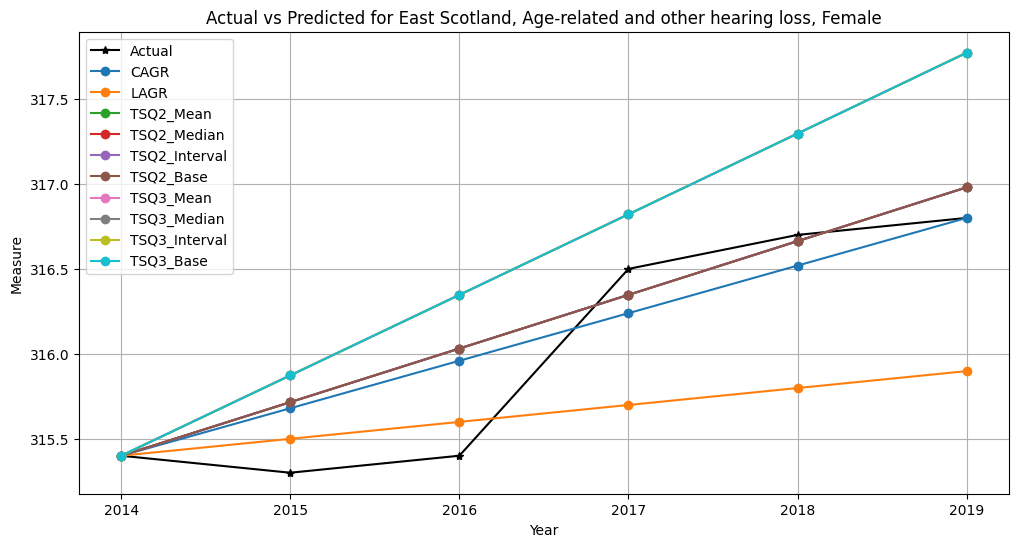

In [10]:
# Plot all the time series together for comparison
plt.figure(figsize=(12, 6))
plt.plot(years, actuals, label="Actual", color="black", marker='*')
plt.plot(years, preds_cagr, label="CAGR", marker='o')
plt.plot(years, preds_lagr, label="LAGR", marker='o')
# plt.plot(years, preds_tsq1_mean, label="TSQ1_Mean", marker='o')
# plt.plot(years, preds_tsq1_median, label="TSQ1_Median", marker='o')
# plt.plot(years, preds_tsq1_interval, label="TSQ1_Interval", marker='o')
# plt.plot(years, preds_tsq1_base, label="TSQ1_Base", marker='o')
plt.plot(years, preds_tsq2_mean, label="TSQ2_Mean", marker='o')
plt.plot(years, preds_tsq2_median, label="TSQ2_Median", marker='o')
plt.plot(years, preds_tsq2_interval, label="TSQ2_Interval", marker='o')
plt.plot(years, preds_tsq2_base, label="TSQ2_Base", marker='o')
plt.plot(years, preds_tsq3_mean, label="TSQ3_Mean", marker='o')
plt.plot(years, preds_tsq3_median, label="TSQ3_Median", marker='o')
plt.plot(years, preds_tsq3_interval, label="TSQ3_Interval", marker='o')
plt.plot(years, preds_tsq3_base, label="TSQ3_Base", marker='o')
plt.xlabel("Year")
plt.ylabel("Measure")
plt.title(f"Actual vs Predicted for {row['Location']}, {row['Cause']}, {row['Sex']}")
plt.legend()
plt.grid()
plt.show()

Compare smoothened curve with the actual curve using RMSE

In [11]:
# METHODS = ["CAGR", "LAGR"] + [f"TSQ1_{norm_mode}" for norm_mode in NORM_MODES] + [f"TSQ2_{norm_mode}" for norm_mode in NORM_MODES] + [f"TSQ3_{norm_mode}" for norm_mode in NORM_MODES]
METHODS = ["CAGR", "LAGR"] + [f"TSQ2_{norm_mode}" for norm_mode in NORM_MODES] + [f"TSQ3_{norm_mode}" for norm_mode in NORM_MODES]
df1 = df.copy()

In [12]:
df1["goodness_of_fit_rmse"] = df1.apply(lambda row:
                                    [tuple([method, goodness_of_fit([t[1] for t in row['YearlyData']], [row['YearlyData'][0][1]*(1 + row[method]/100)**i for i in range(len(row['YearlyData']))])]) for method in METHODS], axis=1)
df1["goodness_of_fit_rmse_winner"] = df1["goodness_of_fit_rmse"].apply(lambda x: min(x, key=lambda t: t[1])[0])
df1["winner_broad_rmse"] = df1["goodness_of_fit_rmse_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df1["goodness_of_fit_rmse_winner"].value_counts(), df1["winner_broad_rmse"].value_counts()

(goodness_of_fit_rmse_winner
 CAGR             922
 TSQ2_mean        393
 TSQ2_base        229
 TSQ2_interval    186
 TSQ2_median      180
 TSQ3_mean        144
 TSQ3_interval     97
 TSQ3_base         83
 TSQ3_median       79
 LAGR              67
 Name: count, dtype: int64,
 winner_broad_rmse
 TSQ2    988
 CAGR    922
 TSQ3    403
 LAGR     67
 Name: count, dtype: int64)

In [13]:
df1["goodness_of_fit_mape"] = df1.apply(lambda row:
                                    [tuple([method, goodness_of_fit([t[1] for t in row['YearlyData']], [row['YearlyData'][0][1]*(1 + row[method]/100)**i for i in range(len(row['YearlyData']))], "mape")]) for method in METHODS], axis=1)
df1["goodness_of_fit_mape_winner"] = df1["goodness_of_fit_mape"].apply(lambda x: min(x, key=lambda t: t[1])[0])
df1["winner_broad_mape"] = df1["goodness_of_fit_mape_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df1["goodness_of_fit_mape_winner"].value_counts(), df1["winner_broad_mape"].value_counts()

/tmp/ipykernel_14258/2754549884.py:37: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.abs((np.array(actuals) - np.array(preds)) / np.array(actuals))) * 100
/tmp/ipykernel_14258/2754549884.py:37: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((np.array(actuals) - np.array(preds)) / np.array(actuals))) * 100


(goodness_of_fit_mape_winner
 CAGR             1521
 TSQ2_mean         217
 TSQ2_interval     165
 TSQ2_base         162
 TSQ2_median       120
 TSQ3_mean          56
 TSQ3_median        44
 TSQ3_interval      35
 TSQ3_base          30
 LAGR               30
 Name: count, dtype: int64,
 winner_broad_mape
 CAGR    1521
 TSQ2     664
 TSQ3     165
 LAGR      30
 Name: count, dtype: int64)

In [14]:
df1["goodness_of_fit_mae"] = df1.apply(lambda row:
                                    [tuple([method, goodness_of_fit([t[1] for t in row['YearlyData']], [row['YearlyData'][0][1]*(1 + row[method]/100)**i for i in range(len(row['YearlyData']))], "mae")]) for method in METHODS], axis=1)
df1["goodness_of_fit_mae_winner"] = df1["goodness_of_fit_mae"].apply(lambda x: min(x, key=lambda t: t[1])[0])
df1["winner_broad_mae"] = df1["goodness_of_fit_mae_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df1["goodness_of_fit_mae_winner"].value_counts(), df1["winner_broad_mae"].value_counts()

(goodness_of_fit_mae_winner
 CAGR             1530
 TSQ2_mean         206
 TSQ2_base         157
 TSQ2_interval     138
 TSQ2_median       116
 TSQ3_mean          79
 TSQ3_interval      61
 TSQ3_median        54
 TSQ3_base          34
 LAGR                5
 Name: count, dtype: int64,
 winner_broad_mae
 CAGR    1530
 TSQ2     617
 TSQ3     228
 LAGR       5
 Name: count, dtype: int64)

In [15]:
df1["goodness_of_fit_rpr"] = df1.apply(lambda row:
                                    [tuple([method, goodness_of_fit([t[1] for t in row['YearlyData']], [row['YearlyData'][0][1]*(1 + row[method]/100)**i for i in range(len(row['YearlyData']))], "rpr")]) for method in METHODS], axis=1)
df1["goodness_of_fit_rpr_winner"] = df1["goodness_of_fit_rpr"].apply(lambda x: min(x, key=lambda t: t[1])[0])
df1["winner_broad_rpr"] = df1["goodness_of_fit_rpr_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df1["goodness_of_fit_rpr_winner"].value_counts(), df1["winner_broad_rpr"].value_counts()

/tmp/ipykernel_14258/2754549884.py:40: RuntimeWarning: invalid value encountered in scalar divide
  return np.std((np.diff(preds))) / np.std((np.diff(actuals)))


(goodness_of_fit_rpr_winner
 TSQ2_mean        550
 CAGR             544
 LAGR             428
 TSQ3_mean        296
 TSQ2_interval    239
 TSQ3_interval    123
 TSQ2_median      122
 TSQ3_median       66
 TSQ2_base          7
 TSQ3_base          5
 Name: count, dtype: int64,
 winner_broad_rpr
 TSQ2    918
 CAGR    544
 TSQ3    490
 LAGR    428
 Name: count, dtype: int64)

In [16]:
indices_won = {method: sorted(list(set(df1[df1["goodness_of_fit_rpr_winner"] == method].index))) for method in METHODS}

### Linear Regression Fit

In [17]:
df2 = df.copy()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2298 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [18]:
# For each time series in df2, fit a linear regression line and calculate the R^2 value as a measure of goodness of fit. Add the R^2 value as a new column in the dataframe.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def fit_linear_regression(yearly_data):
    years = np.array([t[0] for t in yearly_data]).reshape(-1, 1)
    measures = np.array([t[1] for t in yearly_data])
    model = LinearRegression()
    model.fit(years, measures)
    preds = model.predict(years)
    r2 = r2_score(measures, preds)
    return r2
df2["linear_regression_r2"] = df2["YearlyData"].apply(fit_linear_regression)
df2["linear_regression_r2"].describe()

count    2380.000000
mean        0.326432
std         0.312827
min         0.000001
25%         0.044573
50%         0.210114
75%         0.587423
max         1.000000
Name: linear_regression_r2, dtype: float64

/tmp/ipykernel_14258/57163345.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=METHODS)


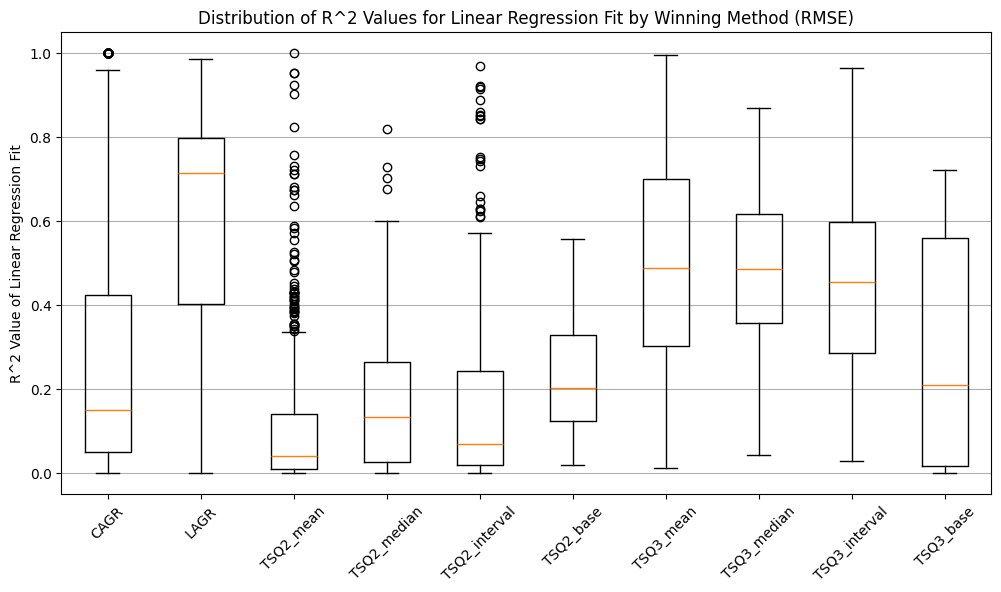

In [19]:
# For each method in METHODS, get the range of R^2 values for the rows where that method was the winner according to RMSE. Plot the distribution of R^2 values for each method using a boxplot.
plt.figure(figsize=(12, 6))
data = []
for method in METHODS:
    indices = indices_won[method]
    r2_values = df2.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
plt.boxplot(data, labels=METHODS)
plt.xticks(rotation=45)
plt.ylabel("R^2 Value of Linear Regression Fit")
plt.title("Distribution of R^2 Values for Linear Regression Fit by Winning Method (RMSE)")
plt.grid(axis='y')
plt.show()

In [20]:
data = []
for method in METHODS:
    indices = indices_won[method]
    r2_values = df2.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
[tuple([a, round(float(np.mean(d)),3), round(float(np.median(d)),3), round(float(np.std(d)),3)]) for (a, d) in zip(METHODS, data)]

[('CAGR', 0.297, 0.149, 0.341),
 ('LAGR', 0.591, 0.712, 0.286),
 ('TSQ2_mean', 0.111, 0.039, 0.17),
 ('TSQ2_median', 0.186, 0.131, 0.198),
 ('TSQ2_interval', 0.176, 0.069, 0.232),
 ('TSQ2_base', 0.24, 0.203, 0.169),
 ('TSQ3_mean', 0.492, 0.487, 0.233),
 ('TSQ3_median', 0.478, 0.484, 0.207),
 ('TSQ3_interval', 0.456, 0.454, 0.225),
 ('TSQ3_base', 0.301, 0.21, 0.291)]

### Roughness preserving

The paper [ASAP: Prioritizing Attention via Time Series Smoothing](https://dl.acm.org/doi/10.14778/3137628.3137645) defined roughness of a time-series as the standard deviation of the first difference:

$$
\Delta X = \{\Delta X_i\}_{i=1}^{N-1}
$$

where $\Delta X_i = X_{i+1} - X_i$ $i \in \{1,2,...,(N-1)\}$. So here, we calculate roughness for each of the time series and see if that gives a characteristic of which growth rate works better.

In [21]:
df3 = df.copy()
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2298 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [22]:
a = set(df3.index[df3["CAGR"].isna()])
b = set(df3.index[df3["LAGR"].isna()])
len(a), len(b), len(a.intersection(b)), len(a.union(b))

(86, 82, 73, 95)

In [23]:
def get_std_dev_first_differences(values:list):
    if len(values) < 2:
        return None
    diffs = [values[i] - values[i-1] for i in range(1, len(values))]
    return np.std(diffs)

df3["std_first_diff"] = df3["YearlyData"].apply(lambda x: get_std_dev_first_differences([t[1] for t in x]))
df3["std_first_diff"].describe()

count    2380.000000
mean       90.779580
std       139.525115
min         0.000000
25%        12.431025
50%        45.952192
75%       105.312990
max      1461.472209
Name: std_first_diff, dtype: float64

/tmp/ipykernel_14258/3560708472.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=METHODS)


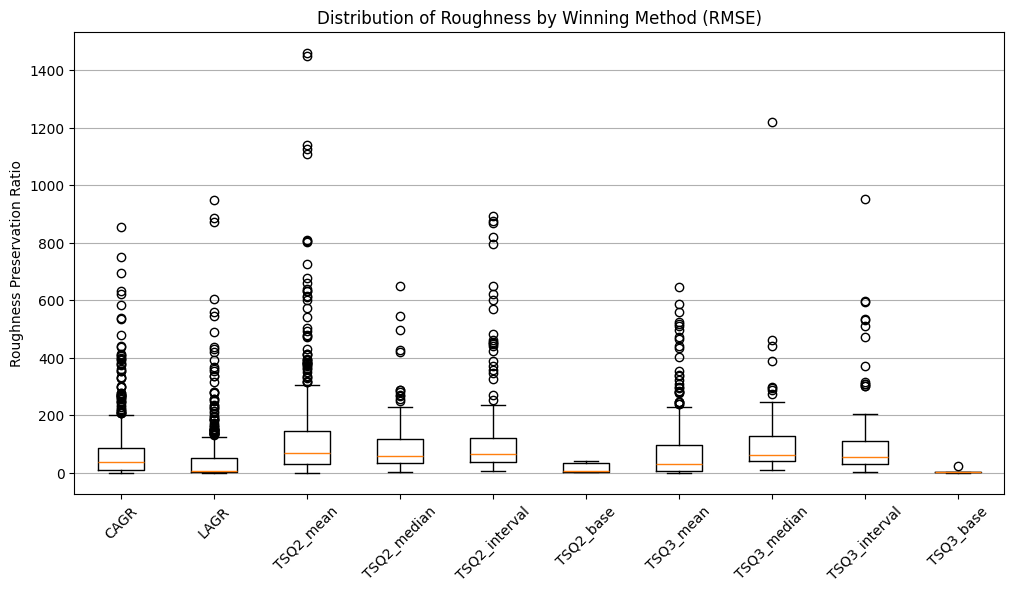

In [24]:
# For each method in METHODS, get the range of stddedv values for the rows where that method was the winner according to RMSE. Plot the distribution of stddev values for each method using a boxplot.
plt.figure(figsize=(12, 6))
data = []
for method in METHODS:
    indices = indices_won[method]
    r2_values = df3.loc[indices, "std_first_diff"].values
    data.append(r2_values)
plt.boxplot(data, labels=METHODS)
plt.xticks(rotation=45)
plt.ylabel("Roughness Preservation Ratio")
plt.title("Distribution of Roughness by Winning Method (RMSE)")
plt.grid(axis='y')
plt.show()

In [25]:
data = []
for method in METHODS:
    indices = indices_won[method]
    r2_values = df3.loc[indices, "std_first_diff"].values
    data.append(r2_values)
[tuple([a, round(float(np.mean(d)),3), round(float(np.median(d)),3), round(float(np.std(d)),3)]) for (a, d) in zip(METHODS, data)]

[('CAGR', 75.254, 38.079, 112.142),
 ('LAGR', 53.511, 5.433, 115.822),
 ('TSQ2_mean', 123.367, 69.36, 171.721),
 ('TSQ2_median', 95.995, 57.722, 108.854),
 ('TSQ2_interval', 117.905, 64.931, 156.004),
 ('TSQ2_base', 16.948, 4.34, 16.054),
 ('TSQ3_mean', 78.741, 31.473, 116.698),
 ('TSQ3_median', 122.333, 62.078, 170.795),
 ('TSQ3_interval', 105.211, 53.713, 145.21),
 ('TSQ3_base', 6.141, 2.494, 8.273)]

### Fractal dimension

Fractal dimension acts as a measure of roughness: a smooth, differentiable curve has a dimension of 1, while a highly irregular, rough curve has a dimension approaching 2. According to [Estimators of Fractal Dimension : Assessing the Roughness of Time Series and Spatial Data](https://www.semanticscholar.org/paper/Estimators-of-Fractal-Dimension-%3A-Assessing-the-of-Gneiting-Percival/fa0534a901056b35fff9cfa84143b6ed2d8f1153), for time-series they use the **Madogram estimator**, is a statistically more efficient version of the Hall-Wood estimator and is highly robust against outliers.

The recommended madogram estimator relies on calculating the power variation of order $p=1$ at different lags (scales) $l$. For a time series with $n+1$ observations, the variation at lag $l$ is:
$$\hat{V}_{p}(l/n) = \frac{1}{2(n-l)} \sum_{i=l}^{n} |X_{i/n} - X_{(i-l)/n}|^{p}$$
Using the two smallest lags ($l=1$ and $l=2$) to minimize bias, the fractal dimension is estimated using a log-log regression slope formula:$$\hat{D}_{V;p} = 2 - \frac{1}{p} \frac{\log \hat{V}_{p}(2/n) - \log \hat{V}_{p}(1/n)}{\log 2}$$

In [26]:
def estimate_fractal_dimension_madogram(time_series):
    """
    Estimates the fractal dimension of a 1D time series using the 
    madogram estimator (power variation with p=1) recommended by Gneiting et al.
    
    Parameters:
    time_series (array-like): A 1D array of equally spaced time series data.
    
    Returns:
    float: The estimated fractal dimension (typically between 1.0 and 2.0).
    """
    X = np.asarray(time_series)
    n = len(X) - 1  # The paper uses n as the number of intervals (length - 1)
    
    if n < 2:
        raise ValueError("Time series is too short to estimate fractal dimension.")
        
    p = 1.0 # Madogram power index
    
    # Calculate variation at lag 1 (l=1)
    # Using vectorized operations: sum of absolute differences between adjacent points
    diff_l1 = np.abs(X[1:] - X[:-1])
    v_1 = np.sum(diff_l1**p) / (2 * (n - 1))
    
    # Calculate variation at lag 2 (l=2)
    # Using vectorized operations: sum of absolute differences between points 2 steps apart
    diff_l2 = np.abs(X[2:] - X[:-2])
    v_2 = np.sum(diff_l2**p) / (2 * (n - 2))

    # If the total variation is effectively zero, the series is a flat line.
    # A perfectly smooth line has a fractal dimension of 1.0.
    if v_1 <= 1e-12 or v_2 <= 1e-12:
        return 1.0
    
    # Calculate fractal dimension using the log-log formula
    # D = 2 - (1/p) * (log(V(2/n)) - log(V(1/n))) / log(2)
    fractal_dimension = 2.0 - (1.0 / p) * (np.log(v_2) - np.log(v_1)) / np.log(2.0)
    
    return fractal_dimension

# --- Example Usage ---
if __name__ == "__main__":
    # Generate a simple random walk (Brownian motion) as a test case
    # Theoretical dimension of standard Brownian motion is ~1.5
    np.random.seed(42)
    random_walk = np.cumsum(np.random.normal(0, 1, 10000))
    
    d_est = estimate_fractal_dimension_madogram(random_walk)
    print(f"Estimated Fractal Dimension: {d_est:.4f}")

Estimated Fractal Dimension: 1.5121


In [27]:
df4 = df.copy()
df4["fractal_dimension"] = df4["YearlyData"].apply(lambda x: estimate_fractal_dimension_madogram([t[1] for t in x]))
df4["fractal_dimension"].describe()

count    2380.000000
mean        1.679326
std         0.660868
min         0.584963
25%         1.190327
50%         1.600743
75%         2.106578
max         5.170815
Name: fractal_dimension, dtype: float64

/tmp/ipykernel_14258/1383081483.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=METHODS)


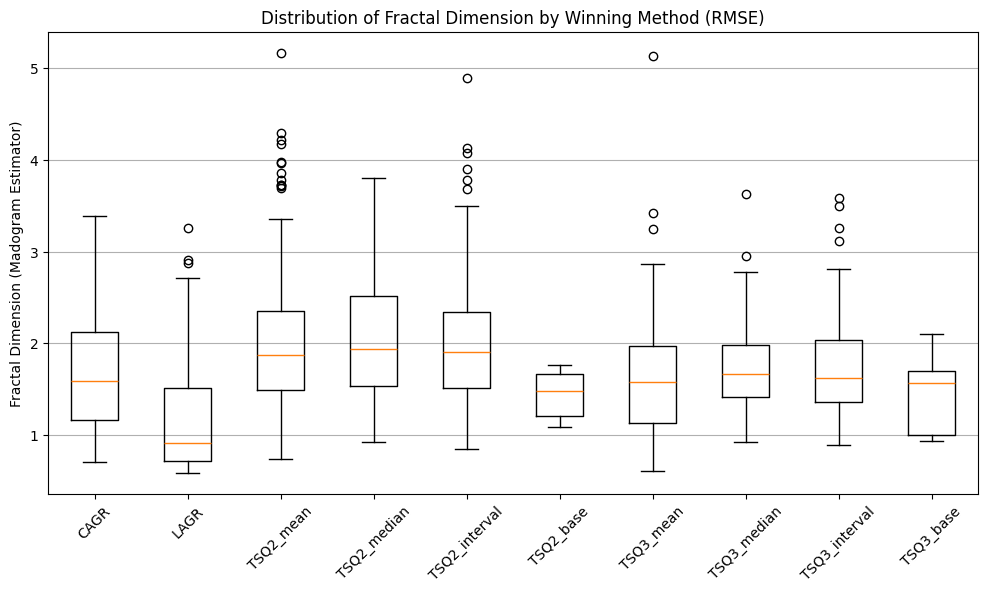

In [28]:
# For each method in METHODS, get the range of fractal dimension values for the rows where that method was the winner according to RMSE. Plot the distribution of stddev values for each method using a boxplot.
plt.figure(figsize=(12, 6))
data = []
for method in METHODS:
    indices = indices_won[method]
    r2_values = df4.loc[indices, "fractal_dimension"].values
    data.append(r2_values)
plt.boxplot(data, labels=METHODS)
plt.xticks(rotation=45)
plt.ylabel("Fractal Dimension (Madogram Estimator)")
plt.title("Distribution of Fractal Dimension by Winning Method (RMSE)")
plt.grid(axis='y')
plt.show()

In [29]:
data = []
for method in METHODS:
    indices = indices_won[method]
    r2_values = df4.loc[indices, "fractal_dimension"].values
    data.append(r2_values)
[tuple([a, round(float(np.mean(d)),3), round(float(np.median(d)),3), round(float(np.std(d)),3)]) for (a, d) in zip(METHODS, data)]

[('CAGR', 1.671, 1.584, 0.58),
 ('LAGR', 1.128, 0.905, 0.529),
 ('TSQ2_mean', 1.941, 1.872, 0.622),
 ('TSQ2_median', 2.005, 1.934, 0.588),
 ('TSQ2_interval', 1.993, 1.908, 0.643),
 ('TSQ2_base', 1.435, 1.472, 0.252),
 ('TSQ3_mean', 1.598, 1.574, 0.635),
 ('TSQ3_median', 1.732, 1.662, 0.489),
 ('TSQ3_interval', 1.72, 1.62, 0.561),
 ('TSQ3_base', 1.462, 1.569, 0.441)]

## Forecasting

### Linear regression

In [30]:
df5 = df.copy()
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2298 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [31]:
# Calculate growth rates for each time series 2014-18 and add them as new columns in the dataframe
df5["CAGR"] = df5["YearlyData"].apply(lambda x: get_cagr([t[1] for t in x if 2014 <= t[0] <= 2018]))
df5["LAGR"] = df5["YearlyData"].apply(lambda x: get_lagr([t[1] for t in x if 2014 <= t[0] <= 2018]))
for q in range(2,4):
    for mode in NORM_MODES:
        df5[f"TSQ{q}_{mode}"] = df5["YearlyData"].apply(lambda x: get_tsq(dict([t for t in x if 2014 <= t[0] <= 2018]), q=q, norm_mode=mode))
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2293 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [32]:
# Take 2014-18 data, fit straight line and calculate R^2 value
df5["linear_regression_r2"] = df5["YearlyData"].apply(lambda x: fit_linear_regression([t for t in x if 2014 <= t[0] <= 2018]))

for method in METHODS:
    df5[f"{method}_pred"] = df5.apply(lambda row: dict(row["YearlyData"]).get(2018)*(1 + row[method]/100), axis=1)
df5["forecasting_winner"] = df5.apply(lambda row: min([(method, abs(dict(row["YearlyData"]).get(2019) - row[f"{method}_pred"])) for method in METHODS], key=lambda t: t[1])[0], axis=1)
df5["forecasting_winner_category"] = df5["forecasting_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df5["forecasting_winner"].value_counts(), df5["forecasting_winner_category"].value_counts()

(forecasting_winner
 LAGR             697
 CAGR             399
 TSQ3_base        299
 TSQ3_mean        209
 TSQ2_mean        196
 TSQ2_base        164
 TSQ2_interval    148
 TSQ2_median       93
 TSQ3_interval     92
 TSQ3_median       83
 Name: count, dtype: int64,
 forecasting_winner_category
 LAGR    697
 TSQ3    683
 TSQ2    601
 CAGR    399
 Name: count, dtype: int64)

In [33]:
regression_winner_indices = {method: sorted(list(set(df5[df5["forecasting_winner"] == method].index))) for method in METHODS}
regression_winner_indices

{'CAGR': [3,
  12,
  14,
  19,
  26,
  28,
  37,
  43,
  47,
  50,
  54,
  62,
  63,
  68,
  69,
  80,
  83,
  94,
  95,
  102,
  109,
  119,
  120,
  124,
  129,
  137,
  141,
  146,
  164,
  170,
  175,
  180,
  186,
  187,
  199,
  202,
  209,
  212,
  214,
  228,
  235,
  248,
  249,
  259,
  260,
  265,
  266,
  272,
  273,
  283,
  291,
  318,
  333,
  341,
  345,
  349,
  357,
  366,
  367,
  374,
  375,
  389,
  400,
  402,
  412,
  413,
  414,
  418,
  424,
  426,
  446,
  449,
  450,
  454,
  459,
  460,
  463,
  467,
  486,
  489,
  501,
  509,
  514,
  515,
  519,
  522,
  527,
  529,
  540,
  552,
  553,
  554,
  555,
  561,
  565,
  579,
  580,
  584,
  587,
  588,
  593,
  594,
  607,
  612,
  617,
  622,
  624,
  629,
  636,
  640,
  642,
  643,
  644,
  649,
  652,
  653,
  654,
  655,
  659,
  661,
  665,
  669,
  672,
  676,
  680,
  687,
  691,
  692,
  693,
  716,
  720,
  724,
  732,
  734,
  744,
  747,
  769,
  774,
  777,
  788,
  794,
  795,
  808,
  809,
  81

/tmp/ipykernel_14258/3430636372.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=METHODS)


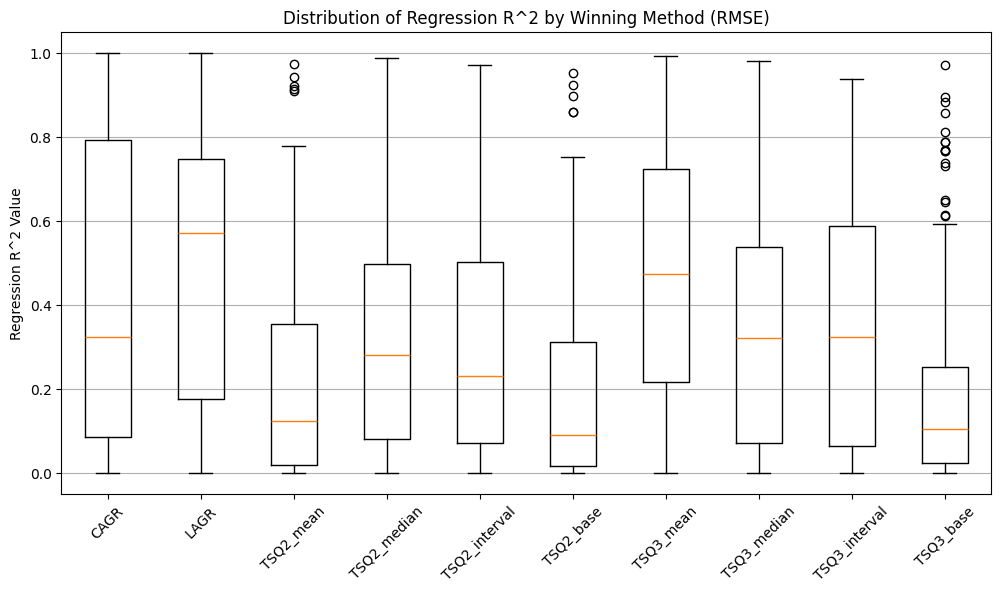

In [34]:
# For each method in METHODS, get the range of fractal dimension values for the rows where that method was the winner according to RMSE. Plot the distribution of stddev values for each method using a boxplot.
plt.figure(figsize=(12, 6))
data = []
for method in METHODS:
    indices = regression_winner_indices[method]
    r2_values = df5.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
plt.boxplot(data, labels=METHODS)
plt.xticks(rotation=45)
plt.ylabel("Regression R^2 Value")
plt.title("Distribution of Regression R^2 by Winning Method (RMSE)")
plt.grid(axis='y')
plt.show()

In [35]:
data = []
for method in METHODS:
    indices = regression_winner_indices[method]
    r2_values = df5.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
[tuple([a, round(float(np.mean(d)),3), round(float(np.median(d)),3), round(float(np.std(d)),3)]) for (a, d) in zip(METHODS, data)]

[('CAGR', 0.427, 0.324, 0.374),
 ('LAGR', 0.488, 0.571, 0.3),
 ('TSQ2_mean', 0.217, 0.123, 0.243),
 ('TSQ2_median', 0.336, 0.279, 0.279),
 ('TSQ2_interval', 0.31, 0.231, 0.271),
 ('TSQ2_base', 0.204, 0.09, 0.235),
 ('TSQ3_mean', 0.453, 0.473, 0.289),
 ('TSQ3_median', 0.33, 0.32, 0.282),
 ('TSQ3_interval', 0.357, 0.324, 0.278),
 ('TSQ3_base', 0.175, 0.104, 0.204)]

### 2-step ahead prediction

In [36]:
df6 = df.copy()
df6.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2298 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [37]:
# Calculate growth rates for each time series 2014-18 and add them as new columns in the dataframe
df6["CAGR"] = df6["YearlyData"].apply(lambda x: get_cagr([t[1] for t in x if 2014 <= t[0] <= 2017]))
df6["LAGR"] = df6["YearlyData"].apply(lambda x: get_lagr([t[1] for t in x if 2014 <= t[0] <= 2017]))
for q in range(2,4):
    for mode in NORM_MODES:
        df6[f"TSQ{q}_{mode}"] = df6["YearlyData"].apply(lambda x: get_tsq(dict([t for t in x if 2014 <= t[0] <= 2017]), q=q, norm_mode=mode))
df6.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2292 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [38]:
def get_mae(actuals, preds):
    return np.mean(np.abs(np.array(actuals) - np.array(preds)))

In [39]:
# Take 2014-18 data, fit straight line and calculate R^2 value
df6["linear_regression_r2"] = df6["YearlyData"].apply(lambda x: fit_linear_regression([t for t in x if 2014 <= t[0] <= 2017]))

for method in METHODS:
    df6[f"{method}_pred"] = df6.apply(lambda row: [dict(row["YearlyData"]).get(2017)*(1 + row[method]/100)**(i+1) for i in range(2)], axis=1)
df6["forecasting_winner"] = df6.apply(lambda row: min([(method, get_mae([dict(row["YearlyData"]).get(yr) for yr in [2018, 2019]], row[f"{method}_pred"])) for method in METHODS], key=lambda t: t[1])[0], axis=1)
df6["forecasting_winner_category"] = df6["forecasting_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df6["forecasting_winner"].value_counts(), df6["forecasting_winner_category"].value_counts()

(forecasting_winner
 CAGR             459
 TSQ2_mean        417
 LAGR             403
 TSQ3_mean        323
 TSQ3_base        187
 TSQ2_interval    186
 TSQ2_base        135
 TSQ2_median      114
 TSQ3_interval     88
 TSQ3_median       68
 Name: count, dtype: int64,
 forecasting_winner_category
 TSQ2    852
 TSQ3    666
 CAGR    459
 LAGR    403
 Name: count, dtype: int64)

In [40]:
regression_winner_indices = {method: sorted(list(set(df6[df6["forecasting_winner"] == method].index))) for method in METHODS}
regression_winner_indices

{'CAGR': [2,
  12,
  19,
  22,
  24,
  26,
  28,
  33,
  38,
  42,
  43,
  47,
  48,
  49,
  67,
  69,
  87,
  95,
  101,
  109,
  111,
  116,
  117,
  120,
  123,
  125,
  129,
  136,
  148,
  155,
  159,
  171,
  172,
  174,
  183,
  187,
  188,
  189,
  195,
  201,
  204,
  209,
  212,
  218,
  222,
  224,
  234,
  235,
  237,
  239,
  245,
  249,
  250,
  260,
  272,
  273,
  279,
  283,
  302,
  309,
  318,
  323,
  341,
  349,
  373,
  374,
  375,
  386,
  387,
  389,
  398,
  400,
  403,
  404,
  405,
  409,
  412,
  413,
  418,
  419,
  436,
  443,
  445,
  448,
  449,
  455,
  458,
  460,
  463,
  467,
  472,
  479,
  481,
  487,
  489,
  494,
  501,
  503,
  514,
  515,
  516,
  518,
  522,
  526,
  528,
  529,
  533,
  534,
  540,
  544,
  548,
  552,
  553,
  554,
  562,
  576,
  579,
  580,
  588,
  593,
  594,
  600,
  607,
  612,
  617,
  629,
  631,
  635,
  636,
  638,
  640,
  649,
  650,
  651,
  653,
  654,
  655,
  659,
  660,
  662,
  668,
  669,
  672,
  677,
  6

/tmp/ipykernel_14258/82223723.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=METHODS)


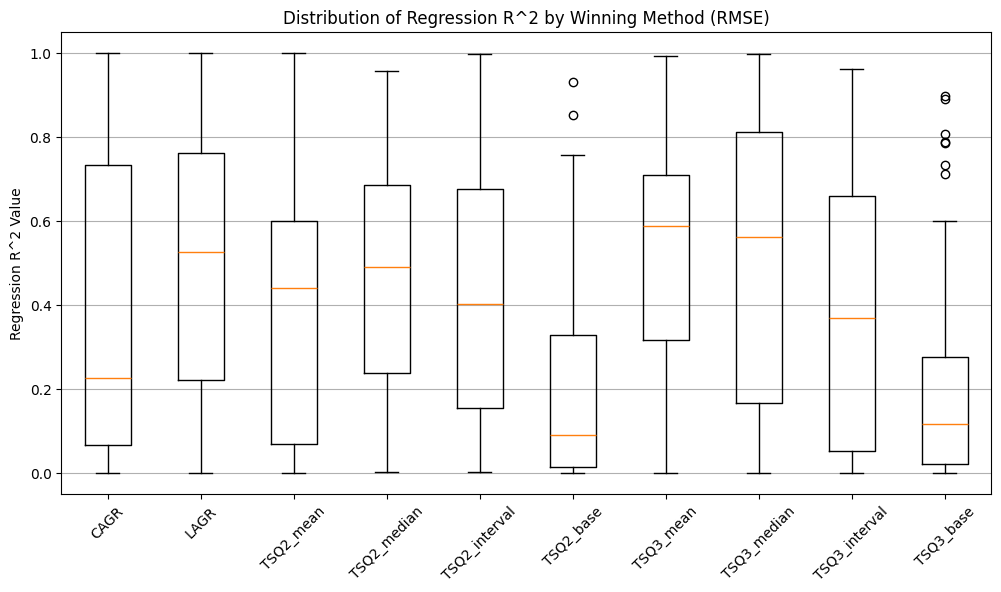

In [41]:
# For each method in METHODS, get the range of fractal dimension values for the rows where that method was the winner according to RMSE. Plot the distribution of stddev values for each method using a boxplot.
plt.figure(figsize=(12, 6))
data = []
for method in METHODS:
    indices = regression_winner_indices[method]
    r2_values = df6.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
plt.boxplot(data, labels=METHODS)
plt.xticks(rotation=45)
plt.ylabel("Regression R^2 Value")
plt.title("Distribution of Regression R^2 by Winning Method (RMSE)")
plt.grid(axis='y')
plt.show()

In [42]:
data = []
for method in METHODS:
    indices = regression_winner_indices[method]
    r2_values = df6.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
[tuple([a, round(float(np.mean(d)),3), round(float(np.median(d)),3), round(float(np.std(d)),3)]) for (a, d) in zip(METHODS, data)]

[('CAGR', 0.389, 0.225, 0.372),
 ('LAGR', 0.496, 0.527, 0.309),
 ('TSQ2_mean', 0.378, 0.439, 0.291),
 ('TSQ2_median', 0.466, 0.49, 0.268),
 ('TSQ2_interval', 0.419, 0.402, 0.294),
 ('TSQ2_base', 0.209, 0.089, 0.241),
 ('TSQ3_mean', 0.515, 0.588, 0.266),
 ('TSQ3_median', 0.517, 0.561, 0.336),
 ('TSQ3_interval', 0.371, 0.369, 0.303),
 ('TSQ3_base', 0.174, 0.115, 0.197)]

### 3-step ahead

In [43]:
df7 = df.copy()
df7.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2298 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [44]:
df7["CAGR"] = df7["YearlyData"].apply(lambda x: get_cagr([t[1] for t in x if 2014 <= t[0] <= 2016]))
df7["LAGR"] = df7["YearlyData"].apply(lambda x: get_lagr([t[1] for t in x if 2014 <= t[0] <= 2016]))
for q in range(2,4):
    for mode in NORM_MODES:
        df7[f"TSQ{q}_{mode}"] = df7["YearlyData"].apply(lambda x: get_tsq(dict([t for t in x if 2014 <= t[0] <= 2016]), q=q, norm_mode=mode))
df7.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2380 non-null   str    
 1   Cause          2380 non-null   str    
 2   Sex            2380 non-null   str    
 3   YearlyData     2380 non-null   object 
 4   CAGR           2294 non-null   float64
 5   LAGR           2287 non-null   float64
 6   TSQ2_mean      2380 non-null   float64
 7   TSQ2_median    2380 non-null   float64
 8   TSQ2_interval  2380 non-null   float64
 9   TSQ2_base      2380 non-null   float64
 10  TSQ3_mean      2380 non-null   float64
 11  TSQ3_median    2380 non-null   float64
 12  TSQ3_interval  2380 non-null   float64
 13  TSQ3_base      2380 non-null   float64
dtypes: float64(10), object(1), str(3)
memory usage: 260.4+ KB


In [45]:
df7["linear_regression_r2"] = df7["YearlyData"].apply(lambda x: fit_linear_regression([t for t in x if 2014 <= t[0] <= 2016]))

for method in METHODS:
    df7[f"{method}_pred"] = df7.apply(lambda row: [dict(row["YearlyData"]).get(2016)*(1 + row[method]/100)**(i+1) for i in range(3)], axis=1)
df7["forecasting_winner"] = df7.apply(lambda row: min([(method, get_mae([dict(row["YearlyData"]).get(yr) for yr in [2017, 2018, 2019]], row[f"{method}_pred"])) for method in METHODS], key=lambda t: t[1])[0], axis=1)
df7["forecasting_winner_category"] = df7["forecasting_winner"].apply(lambda x: x.split("_")[0] if "_" in x else x)
df7["forecasting_winner"].value_counts(), df7["forecasting_winner_category"].value_counts()

(forecasting_winner
 LAGR             721
 TSQ2_interval    435
 CAGR             324
 TSQ2_mean        272
 TSQ3_median      190
 TSQ3_mean        187
 TSQ3_base        104
 TSQ2_median       89
 TSQ2_base         58
 Name: count, dtype: int64,
 forecasting_winner_category
 TSQ2    854
 LAGR    721
 TSQ3    481
 CAGR    324
 Name: count, dtype: int64)

In [46]:
regression_winner_indices = {method: sorted(list(set(df7[df7["forecasting_winner"] == method].index))) for method in METHODS}
regression_winner_indices

{'CAGR': [1,
  35,
  47,
  69,
  73,
  80,
  82,
  83,
  85,
  109,
  120,
  126,
  132,
  135,
  136,
  140,
  144,
  147,
  170,
  171,
  184,
  187,
  204,
  209,
  222,
  223,
  227,
  234,
  249,
  250,
  259,
  260,
  272,
  273,
  276,
  277,
  279,
  288,
  316,
  327,
  328,
  332,
  340,
  349,
  356,
  362,
  363,
  365,
  369,
  374,
  375,
  389,
  398,
  400,
  409,
  412,
  413,
  416,
  418,
  421,
  434,
  447,
  448,
  463,
  467,
  470,
  476,
  477,
  489,
  503,
  504,
  514,
  515,
  525,
  529,
  540,
  552,
  553,
  554,
  556,
  566,
  579,
  607,
  610,
  622,
  629,
  636,
  653,
  654,
  655,
  662,
  669,
  677,
  680,
  686,
  690,
  693,
  714,
  716,
  731,
  733,
  747,
  748,
  751,
  762,
  766,
  769,
  784,
  794,
  795,
  799,
  804,
  809,
  820,
  824,
  832,
  833,
  836,
  887,
  890,
  903,
  909,
  922,
  934,
  935,
  943,
  945,
  949,
  960,
  972,
  973,
  974,
  976,
  977,
  980,
  987,
  994,
  1002,
  1011,
  1016,
  1027,
  1030,
  1

/tmp/ipykernel_14258/2208693231.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=METHODS)


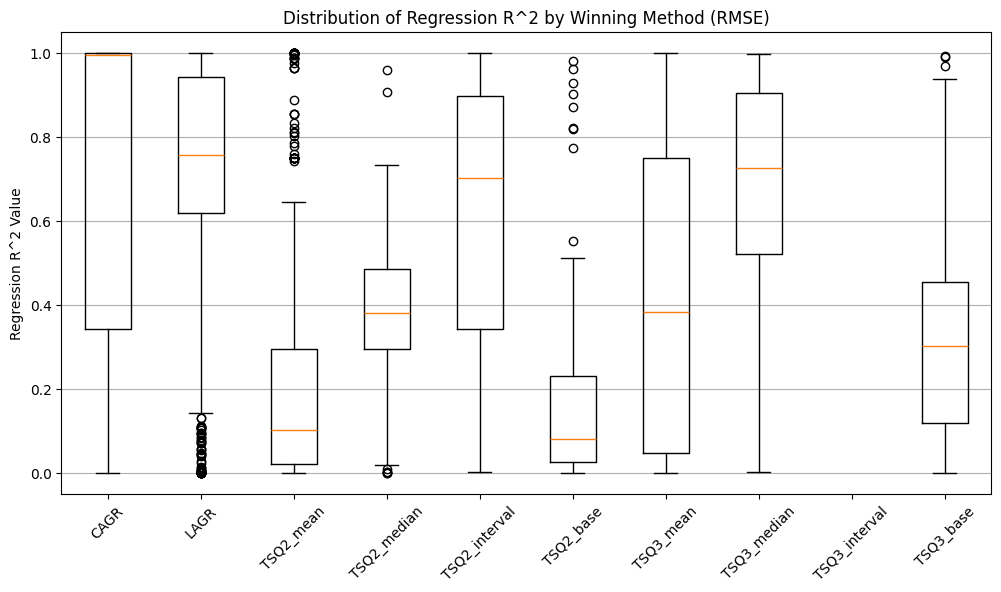

In [47]:
# For each method in METHODS, get the range of fractal dimension values for the rows where that method was the winner according to RMSE. Plot the distribution of stddev values for each method using a boxplot.
plt.figure(figsize=(12, 6))
data = []
for method in METHODS:
    indices = regression_winner_indices[method]
    r2_values = df7.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
plt.boxplot(data, labels=METHODS)
plt.xticks(rotation=45)
plt.ylabel("Regression R^2 Value")
plt.title("Distribution of Regression R^2 by Winning Method (RMSE)")
plt.grid(axis='y')
plt.show()

In [48]:
data = []
for method in METHODS:
    indices = regression_winner_indices[method]
    r2_values = df7.loc[indices, "linear_regression_r2"].values
    data.append(r2_values)
[tuple([a, round(float(np.mean(d)),3), round(float(np.median(d)),3), round(float(np.std(d)),3)]) for (a, d) in zip(METHODS, data)]

/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[('CAGR', 0.714, 0.994, 0.394),
 ('LAGR', 0.722, 0.757, 0.27),
 ('TSQ2_mean', 0.276, 0.103, 0.352),
 ('TSQ2_median', 0.392, 0.38, 0.187),
 ('TSQ2_interval', 0.614, 0.702, 0.316),
 ('TSQ2_base', 0.215, 0.081, 0.296),
 ('TSQ3_mean', 0.407, 0.382, 0.354),
 ('TSQ3_median', 0.665, 0.726, 0.287),
 ('TSQ3_interval', nan, nan, nan),
 ('TSQ3_base', 0.348, 0.303, 0.262)]